<a href="https://colab.research.google.com/github/jokker5502/Machine-Learning-6-SIN-A-Mar-Jul-2026/blob/metrics/Copia_de_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Logistic Regression

In this notebook, we will explore the basics of logistic regression, discuss its assumptions, and see some examples with actual data.

## Import Libraries

First, let's import the necessary libraries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

# Hide warnings
import warnings
warnings.filterwarnings('ignore')

# Logit Function
**The logit function is the natural logarithm of the [odds](https://en.wikipedia.org/wiki/Odds) (log-odds) of the outcome occurring, which is the ratio of the probability of the outcome occurring to the probability of the outcome not occurring.**

Mathematically, the logit function is defined as:


$ logit(p) = \log\left(\frac{p}{1 - p}\right) $



## Sigmoid Function

The logistic function, also known as the sigmoid function, is **the inverse of the logit function**. It is used to transform the linear combination of predictor variables into a probability value between 0 and 1. Mathematically, the sigmoid function is defined as:

$ $

$\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}$

$ $

Let's plot the sigmoid function, which is used to transform the linear combination of predictor variables into a probability value between 0 and 1.


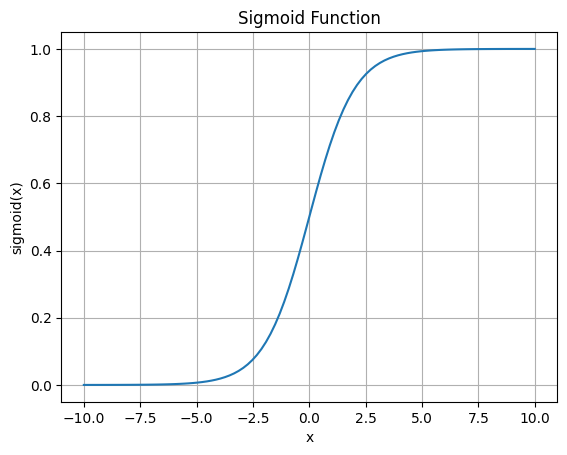

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-10, 10, 100)
y = sigmoid(x)

plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.title('Sigmoid Function')
plt.grid(True)
plt.show()

## Example with Actual Data

Consider a logistic regression model that predicts whether a customer will make a purchase based on their age and income. The model estimates the probability of a purchase occurring given the customer’s age and income, and classifies the customer as a buyer or non-buyer based on a threshold probability value.

Suppose we have the following data:

| Age | Income | Purchased |
|-----|--------|-----------|
| 25  | 50000  | 0         |
| 30  | 60000  | 0         |
| 35  | 70000  | 1         |
| 40  | 80000  | 1         |

Using logistic regression, we can fit a model to this data and predict the probability of a purchase for new customers based on their age and income.

In [ ]:
# Create data
data = {'Age': [25, 30, 35, 40],
        'Income': [50000, 60000, 70000, 80000],
        'Purchased': [0, 0, 1, 1]}

data = pd.DataFrame(data)


# Define features and target variable
X = data[['Age', 'Income']]
y = data['Purchased']

# Fit logistic regression model
model = LogisticRegression()
model.fit(X, y)

# Predict probability of purchase for new customers
new_customer = [[25, 50000]] # example new customer (age 25 & income 50000)

# Get the probability that they will purchase (at index 1)
prob_purchase = model.predict_proba(new_customer)[:,1]

print('Probability of purchase:', round(prob_purchase[0]))

Probability of purchase: 0


Since our model is trained on only 4 datapoints, it's not going to make very nuanced predictions; hence a probability of zero.

## Model Evaluation and Performance Metrics

Now let's start using some real data. For most of the examples that follow, we'll use the [breast cancer dataset](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) because it's small and easy to work with.

Let's first understand some essential machine learning metrics that are used to evaluate the performance of a model.

### Confusion Matrix Definitions
To understand these metrics, we first need to define the components of a **Confusion Matrix**:

*   **True Positive (TP)**: The model correctly predicted the positive class (e.g., correctly identified cancer).
*   **True Negative (TN)**: The model correctly predicted the negative class (e.g., correctly identified a healthy patient).
*   **False Positive (FP)**: The model incorrectly predicted the positive class (Type I error).
*   **False Negative (FN)**: The model incorrectly predicted the negative class (Type II error).

### Key Metrics and Formulas

1. **Accuracy**: The proportion of correctly classified instances out of the total instances.
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

2. **Precision**: The proportion of true positive instances out of the predicted positive instances. It measures how many of the predicted positives are actually positive.
   $$\text{Precision} = \frac{TP}{TP + FP}$$

3. **Recall (Sensitivity)**: The proportion of true positive instances out of the actual positive instances. It measures how many of the actual positives the model captured.
   $$\text{Recall} = \frac{TP}{TP + FN}$$

4. **F1 Score**: The harmonic mean of precision and recall, used to balance the trade-off between the two.
   $$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

5. **ROC AUC Score**: The area under the Receiver Operating Characteristic (ROC) curve, which plots the true positive rate (Recall) against the false positive rate (1 - Specificity).

Let's calculate the F1 score and plot the confusion matrix for a logistic regression model using the breast cancer dataset.

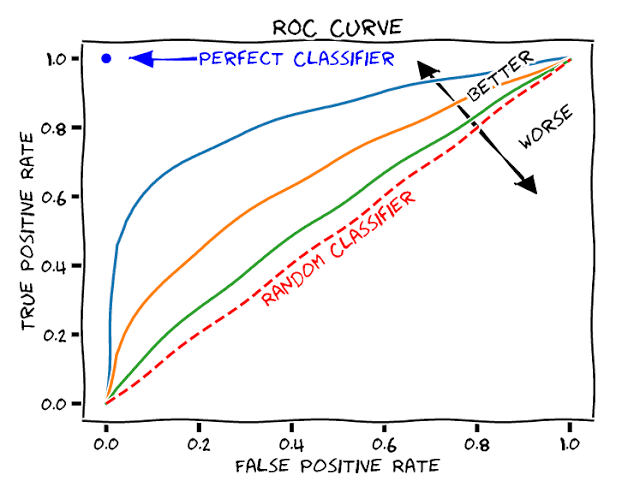



La **ROC Curve** (Receiver Operating Characteristic Curve) es una gráfica que se usa para evaluar qué tan bien funciona un modelo de clasificación binaria, por ejemplo:

* detectar spam / no spam
* enfermedad / sano
* fraude / no fraude

La gráfica compara:

* **Eje X:** tasa de falsos positivos (False Positive Rate, FPR)
* **Eje Y:** tasa de verdaderos positivos (True Positive Rate, TPR)

En términos simples:

* **TPR** = qué tantos positivos reales detecta el modelo.
* **FPR** = qué tantos negativos clasifica incorrectamente como positivos.

---

## ¿Por qué se llama “curva”?

Porque el modelo no da una sola respuesta fija.
Normalmente produce una **probabilidad** o un **score**.

Por ejemplo:

| Persona | Probabilidad de enfermedad |
| ------- | -------------------------- |
| A       | 0.95                       |
| B       | 0.80                       |
| C       | 0.40                       |
| D       | 0.10                       |

Luego eliges un **umbral (threshold)** para decidir:

* si probabilidad > umbral → “positivo”
* si no → “negativo”

Si cambias el umbral:

* cambian los verdaderos positivos
* cambian los falsos positivos

Cada umbral produce un punto distinto en la gráfica.

Al unir todos esos puntos aparece la **curva ROC**.

---

## Interpretación visual de tu imagen

La línea roja punteada representa un clasificador aleatorio:

[
y = x
]

genui{"math_block_widget_always_prefetch_v2":{"content":"y=x"}}

Eso significa que el modelo acierta prácticamente al azar.

---

La esquina superior izquierda representa el clasificador perfecto:

* TPR = 1
* FPR = 0

Es decir:

* detecta todos los positivos
* no comete falsos positivos

---

## ¿Qué significa que una curva sea “mejor”?

Mientras más cerca esté de la esquina superior izquierda:

* mejor detecta positivos
* menos errores comete

Por eso en la imagen:

* la curva azul es mejor
* la verde es peor
* la roja es aleatoria

---

## AUC: el resumen de la ROC

Muchas veces se mide el área bajo la curva:

* **AUC = 1** → perfecto
* **AUC = 0.5** → aleatorio
* **AUC < 0.5** → peor que azar

---

## Intuición rápida

La ROC muestra el intercambio entre:

* detectar más positivos
  vs
* cometer más falsas alarmas

Por eso es tan útil en Machine Learning y medicina.


F1 Score: 0.9655172413793104



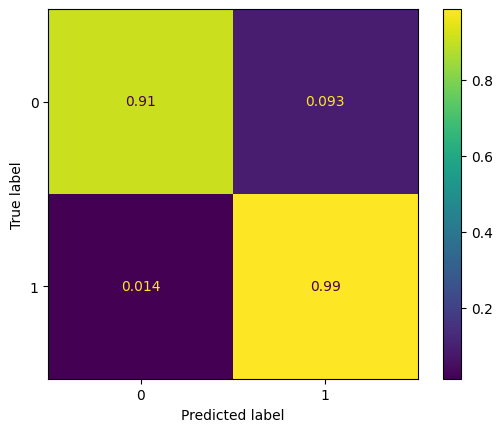

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate F1 score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")
print()

# Plot confusion matrix, normalize='true' to show percentages
cm = confusion_matrix(y_test, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot();

You can see what we correctly identify about 99% of cases and about 9% of the people without cancer would get a false positive. This is a good starting point for our model, but as we continue our work in this notebook you'll see what we can do to diagnose more accurately and responsibly.

But first, let's look at the other metrics:

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy:       {accuracy}")

# Calculate precision
precision = precision_score(y_test, y_pred)
print(f"Precision:      {precision}")

# Calculate recall
recall = recall_score(y_test, y_pred)
print(f"Recall:         {recall}")

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred)
print(f"ROC AUC Score:  {roc_auc}")

Accuracy:       0.956140350877193
Precision:      0.9459459459459459
Recall:         0.9859154929577465
ROC AUC Score:  0.9464461185718965


**Accuracy** is usually not all that helpful, because many machine learning problems you encounter have imbalanced datasets. We could just say no one has cancer and be right most of the time.

Instead, look at the other metrics:

- **Precision**: 94.6% of the cancer diagnoses this model makes are, in fact, cancer.
- **Recall**: 98.6% of the time, when cancer is present, the model correctly diagnoses it.

The ROC-AUC score isn't quite as easy to interpret, but it's a good measure of how well the model is doing overall. If you want some guidelines, an ROC-AUC score between:

- 0.5-0.6 is considered poor
- 0.5-0.6 is considered mediocre
- 0.7-0.8 is considered decent
- 0.8-0.9 is considered good
- 0.9-1.0 is considered excellent

This depends a lot of the dataset itself, too. In fact, sometimes a ROC-AUC score above 0.9 is considered "too good" — meaning there might be data leakage and the model is predicting based on future-based information it wouldn't realistically have.

We know this isn't the case here, though, so we can confidently say that the model's ROC-AUC score of 0.946 is excellent and indicates that the model is performing very well.

# Viewing the coefficients


To view the coefficients generated by a scikit-learn regression, you can create a function that displays the coefficients in a sorted DataFrame.

$ $

1. `model.coef_` contains the coefficients, but it's a 2-dimensional array of numbers. You need to flatten the array before creating the DataFrame.

$ $

2. Create a DataFrame with two columns: 'feature' and 'coefficient'. The 'feature' column should contain the feature names*, and the 'coefficient' column should contain the flattened coefficients.

$ $

3. Sort the DataFrame by the 'coefficient' column in descending order to make it easier to read and analyze.

$ $

\* When you view the coefficients for a dataset that's not built into sklearn, you'll have to do something like `columns=X.columns` or `columns=data.drop('target_column', axis=1).columns` instead.

In [ ]:
coef_df = pd.DataFrame({'feature': data.feature_names, 'coefficient': model.coef_.flatten()})

coef_df.sort_values('coefficient', ascending=False)

,feature,coefficient
11,texture error,1.370567
0,mean radius,1.027437
1,mean texture,0.221451
20,worst radius,0.111653
15,compactness error,0.047361
3,mean area,0.025467
19,fractal dimension error,0.011605
22,worst perimeter,-0.015554
23,worst area,-0.016857
14,smoothness error,-0.022455


# Regularization

Now let's explore regularization techniques in logistic regression, including L1 (Lasso), L2 (Ridge), and Elastic Net regularization. For this section, we'll switch to the Iris dataset, which trains considerably faster than the breast cancer dataset.

The dataset contains 150 samples of iris flowers, with four features:

- Sepal length
- Sepal width
- Petal length
- Petal width

And three target classes:
- Setosa
- Versicolor
- Virginica

$ $

## L1, L2, and Elastic Net regularization

These are techniques used to prevent overfitting and improve model generalization in logistic regression. They work by adding a penalty term to the cost function, which measures how well the model is performing. This penalty term helps control the size of the coefficients (also called weights) in the model. Smaller coefficients usually result in a simpler model that is less likely to overfit.

### Visualization of L1 (Diamond) vs L2 (Circle) Constraints

```python
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 100)
# L2 Circle
x_l2 = np.cos(t)
y_l2 = np.sin(t)

# L1 Diamond
x_l1 = np.array([1, 0, -1, 0, 1])
y_l1 = np.array([0, 1, 0, -1, 0])

plt.figure(figsize=(6,6))
plt.plot(x_l2, y_l2, label='L2 Regularization (Circle)', color='blue', lw=2)
plt.plot(x_l1, y_l1, label='L1 Regularization (Diamond)', color='red', lw=2)
plt.fill(x_l2, y_l2, alpha=0.1, color='blue')
plt.fill(x_l1, y_l1, alpha=0.1, color='red')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title('Constraint Regions: L1 vs L2')
plt.xlabel('Coefficient w1')
plt.ylabel('Coefficient w2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()
```

$ $

**L1 Regularization (Lasso):**

L1 regularization, also known as Lasso, uses the L1-norm as the penalty term. The L1-norm is calculated as the sum of the absolute values of the coefficients. Mathematically, the L1 penalty term is defined as:

`L1_penalty = lambda * sum(abs(coefficients))`

L1 regularization tends to create sparser models, meaning some coefficients will be exactly zero, effectively removing certain features from the model. This can be useful for feature selection, especially when there are many irrelevant features or when interpretability is important.

$ $

**L2 Regularization (Ridge):**

L2 regularization, also known as Ridge, uses the L2-norm as the penalty term. The L2-norm is calculated as the square root of the sum of the squares of the coefficients. Mathematically, the L2 penalty term is defined as:

`L2_penalty = lambda * sum(coefficients ** 2)`

L2 regularization tends to create models with smaller coefficients but does not force them to be exactly zero. This results in a more balanced model that still considers all features but with reduced importance.


![image.png]([Media removed: image/png, ~101800 chars])


$ $

**Elastic Net Regularization:**

Elastic Net regularization is a combination of L1 and L2 regularization. It uses both the L1-norm and the L2-norm as penalty terms, with a mixing parameter (alpha) to control the balance between the two. Mathematically, the Elastic Net penalty term is defined as:

`ElasticNet_penalty = alpha * L1_penalty + (1 - alpha) * L2_penalty`

Elastic Net regularization can provide a balance between the sparsity of L1 regularization and the smoothness of L2 regularization, making it a useful option when it’s unclear which regularization technique to use.

$ $

**Lambda (λ):**

Lambda is a parameter that controls the strength of the regularization effect. A larger lambda value results in a stronger regularization effect, leading to smaller coefficients and a simpler model. Conversely, a smaller lambda value results in a weaker regularization effect, allowing the model to fit the data more closely. Tuning the lambda parameter is crucial for finding the optimal balance between model complexity and fit.

Don't forget that these models use the parameter `C`, which is the inverse of lambda!

$ $

**Alpha:**

Alpha is a parameter used in Elastic Net regularization to control the balance between L1 and L2 penalty terms. Alpha ranges from 0 to 1, where 0 corresponds to pure L2 regularization, 1 corresponds to pure L1 regularization, and values between 0 and 1 result in a mix of L1 and L2 regularization. By adjusting the value of alpha, we can fine-tune the regularization effect to achieve the desired balance between sparsity and smoothness.

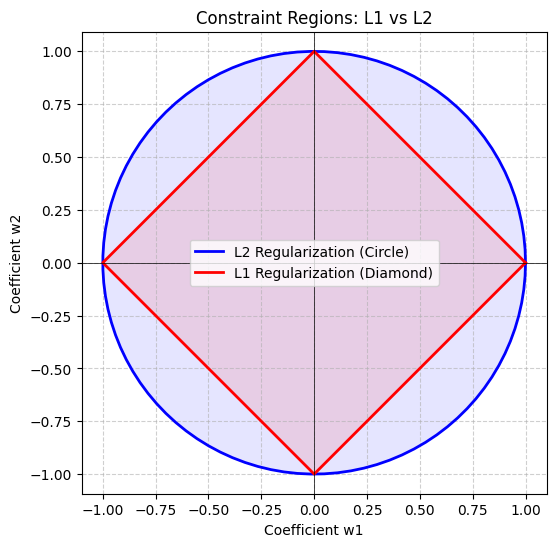

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 2*np.pi, 100)
# L2 Circle
x_l2 = np.cos(t)
y_l2 = np.sin(t)

# L1 Diamond
x_l1 = np.array([1, 0, -1, 0, 1])
y_l1 = np.array([0, 1, 0, -1, 0])

plt.figure(figsize=(6,6))
plt.plot(x_l2, y_l2, label='L2 Regularization (Circle)', color='blue', lw=2)
plt.plot(x_l1, y_l1, label='L1 Regularization (Diamond)', color='red', lw=2)
plt.fill(x_l2, y_l2, alpha=0.1, color='blue')
plt.fill(x_l1, y_l1, alpha=0.1, color='red')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.title('Constraint Regions: L1 vs L2')
plt.xlabel('Coefficient w1')
plt.ylabel('Coefficient w2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

# Load the Iris dataset
data = load_iris()
X, y = data.data, data.target

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Cross-Validation and Grid Search

We will perform 5-fold cross-validation with different regularization strengths and penalties to determine the best model.

ADD 3 GRAPHICAL EXAMPLES EXPLAINING WHAT IS CROSS VALIDATION

In [ ]:
# Create a logistic regression model
model = LogisticRegression(solver='saga', max_iter=5000)

# Create a list of regularization strengths and penalties to test
params = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'penalty': [None, 'l1', 'l2', 'elasticnet'],
    'l1_ratio': [.25, .50, .75] # also called alpha; used for elasticnet
}

# Perform 5-fold cross-validation with different regularization strengths and penalties
clf = GridSearchCV(model, params, cv=5, scoring='accuracy')
clf.fit(X_scaled, y)

# Print the best regularization strength and penalty
print("Best regularization strength:", clf.best_params_['C'])
print("Best penalty:", clf.best_params_['penalty'])

if clf.best_params_['penalty'] == 'elasticnet':
    print("Best alpha:", clf.best_params_['l1_ratio'])

print("Best score:", clf.best_score_)

Best regularization strength: 0.001
Best penalty: None
Best score: 0.9733333333333334


By running the code above, you will get the best regularization strength, penalty, and alpha (for Elastic Net) for the Iris dataset. You can use these parameters to train your final logistic regression model.

# Nonlinear features

In this example, we'll first create a simple dataframe and use the `PolynomialFeatures` class from scikit-learn to generate polynomial features.


In [ ]:
# Simple example

from sklearn.preprocessing import PolynomialFeatures

df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])

poly = PolynomialFeatures(degree=2)

# Make sure to use double brackets around the column name
X_poly = poly.fit_transform(df[['x']])

# Give your new polynomial features descriptive column names
X_poly = pd.DataFrame(X_poly, columns=['x**0', 'x**1', 'x**2'])

# Concat to your original dataframe
df_concat = pd.concat([df, X_poly], axis=1)

df_concat

,x,x**0,x**1,x**2
0,1,1.0,1.0,1.0
1,2,1.0,2.0,4.0
2,3,1.0,3.0,9.0


Now let's do a more advanced example that includes feature interactions.

In [ ]:
# Advanced example
from sklearn.preprocessing import PolynomialFeatures

# Create dataframe with columns
df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])
df['y'] = pd.Series([4,7,11])

# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(df[['x','y']])

X_poly = pd.DataFrame(
  X_poly,
  columns=['bias', 'x', 'y', 'x**2', 'x*y', 'y**2']
)

X_poly

,bias,x,y,x**2,x*y,y**2
0,1.0,1.0,4.0,1.0,4.0,16.0
1,1.0,2.0,7.0,4.0,14.0,49.0
2,1.0,3.0,11.0,9.0,33.0,121.0


## Logarithmic features

For non-integer exponents, such as logarithmic transformations, we can use scikit-learn's `FunctionTransformer`.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import FunctionTransformer

# Create some sample data
df = pd.DataFrame()
df['x'] = pd.Series([1,2,3])
df['y'] = pd.Series([4,7,11])

# Define a function to apply the logarithm transformation
def log_transform(X):
    # it's helpful to add a small constant since log(0) is undefined
    return np.log(X + .01)

# Create a FunctionTransformer with the log_transform function
log_transformer = FunctionTransformer(log_transform)

# Fit and transform the data
X_log = log_transformer.fit_transform(df)

df_concat = pd.concat([df, X_log], axis=1)
df_concat.columns = 'x y log(x) log(y)'.split()

df_concat

,x,y,log(x),log(y)
0,1,4,0.009950,1.388791
1,2,7,0.698135,1.947338
2,3,11,1.101940,2.398804


Now let's try these techniques with a machine learning problem. I'm going to use a diabetes dataset this time, because it's a bit less complex than the breast cancer data and will train faster.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import PolynomialFeatures

# Load diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
data = pd.read_csv(url, names=columns)
X = data.drop('class', axis=1)
y = data['class']

# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Train a logistic regression model without polynomial features
lr = LogisticRegression(max_iter=10000)
lr.fit(X_train, y_train)
y_pred = lr.predict_proba(X_test)[:,1]

print("AUC without polynomial features:", roc_auc_score(y_test, y_pred))

# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train a logistic regression model with polynomial features
lr_poly = LogisticRegression(max_iter=10000)
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict_proba(X_test_poly)[:,1]
print("AUC with polynomial features:", roc_auc_score(y_test, y_pred_poly))

AUC without polynomial features: 0.8644628099173555
AUC with polynomial features: 0.8330578512396695


So this time around, the model actually does worse with added features. Remember that there's no guarantee that feature engineering will improve your model!

What we can try doing instead is engineering the polynomial and logarithmic features, and then using feature selection to remove the ones that aren't improving the model (alternatively you can try regularization).

Unhide the code below if you want to see how I did it.

In [ ]:
#@markdown ## Advanced: create polynomial AND logarithmic features.

#@markdown Click below to view code

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


class LogarithmicFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, base=np.e, ignore_negative=True):
        self.base = base
        self.ignore_negative = ignore_negative

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if self.ignore_negative:
            X[X < 0] = 0
        return np.log(X + .01) / np.log(self.base)


def load_data():
    url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
    names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']
    data = pd.read_csv(url, names=names)
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    return X, y


def train_and_evaluate(X_train, X_test, y_train, y_test, param_grid):
    # Train a logistic regression model without polynomial features using grid search
    lr = LogisticRegression(max_iter=10000)
    grid_search = GridSearchCV(lr, param_grid, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    best_lr = grid_search.best_estimator_
    y_pred = best_lr.predict_proba(X_test)[:, 1]

    print("AUC without polynomial features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters without polynomial features:", grid_search.best_params_)

    # Generate polynomial features
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Generate logarithmic features
    log_features = LogarithmicFeatures()
    X_train_log = log_features.fit_transform(X_train)
    X_test_log = log_features.transform(X_test)

    # Combine polynomial and logarithmic features
    X_train_combined = np.hstack((X_train_poly, X_train_log))
    X_test_combined = np.hstack((X_test_poly, X_test_log))

    # Create a pipeline for feature selection and scaling
    pipeline = Pipeline([
        ('select', SelectKBest(score_func=f_classif)),
        ('scale', StandardScaler()),
        ('lr', LogisticRegression(max_iter=10000))
    ])

    # Update the param_grid to include the pipeline parameters
    param_grid_pipeline = {
        'select__k': range(1, X_train_combined.shape[1] + 1),
        'lr__penalty': param_grid['penalty'],
        'lr__C': param_grid['C'],
        'lr__solver': param_grid['solver']
    }

    # Train a logistic regression model with polynomial features using grid search and pipeline
    grid_search_poly = GridSearchCV(pipeline, param_grid_pipeline, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search_poly.fit(X_train_poly, y_train)
    best_lr = grid_search_poly.best_estimator_
    y_pred = best_lr.predict_proba(X_test_poly)[:, 1]

    print()
    print("AUC with polynomial features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters with polynomial features:", grid_search_poly.best_params_)

    # Train a logistic regression model with both polynomial and logarithmic features using grid search and pipeline
    grid_search_combined = GridSearchCV(pipeline, param_grid_pipeline, scoring='roc_auc', cv=5, n_jobs=-1)
    grid_search_combined.fit(X_train_combined, y_train)
    best_lr = grid_search_combined.best_estimator_
    y_pred = best_lr.predict_proba(X_test_combined)[:, 1]

    print()
    print("AUC with both polynomial and logarithmic features:", roc_auc_score(y_test, y_pred))
    print("Best hyperparameters with both polynomial and logarithmic features:", grid_search_combined.best_params_)


X, y = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

# Define the hyperparameters for grid search
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': np.logspace(-4, 4, 10),
    'solver': ['liblinear']
}

train_and_evaluate(X_train, X_test, y_train, y_test, param_grid)

AUC without polynomial features: 0.8648301193755739
Best hyperparameters without polynomial features: {'C': np.float64(1291.5496650148827), 'penalty': 'l1', 'solver': 'liblinear'}

AUC with polynomial features: 0.850872359963269
Best hyperparameters with polynomial features: {'lr__C': np.float64(0.046415888336127774), 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'select__k': 9}

AUC with both polynomial and logarithmic features: 0.8927456382001837
Best hyperparameters with both polynomial and logarithmic features: {'lr__C': np.float64(0.3593813663804626), 'lr__penalty': 'l2', 'lr__solver': 'liblinear', 'select__k': 42}


Now that we've done some feature transformations, let's look at other ways to improve a model's performance.

$ $

# Addressing Multicollinearity

Multicollinearity occurs when two or more features in a dataset are highly correlated, which can lead to unstable estimates of the model coefficients and reduced interpretability. To detect and handle multicollinearity, we can use the following techniques:

## Correlation matrix

Calculate the correlation coefficients between all pairs of features and visualize them using a heatmap. Features with high correlation coefficients can be considered for removal or combined into a single feature.

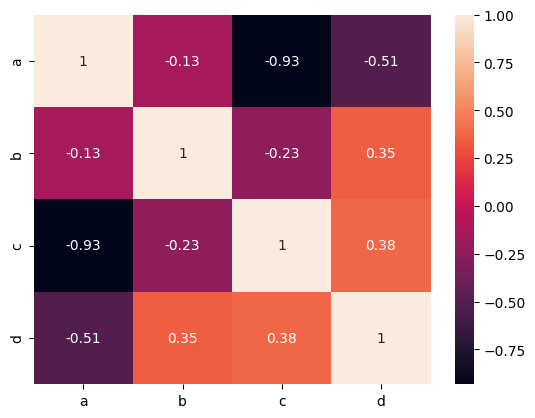

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'a': [1,2,3,4],
    'b': [4,2,4,3],
    'c': [5,5,1,0],
    'd': [2,2,3,0],
})

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True);

This indicates that "a" and "c" have a strong negative correlation and the model might perform better without one.

But take a look at what VIF says...

## Variance Inflation Factor (VIF)

VIF measures the extent to which the variance of a model coefficient is inflated due to multicollinearity. Features with a VIF greater than a certain threshold (e.g., 5 or 10) can be considered for removal or combined into a single feature.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]

# Display VIF
pd.DataFrame({'vif': vif[0:]}, index=df.columns).T

,a,b,c,d
vif,5.454545,12.272727,2.935449,1.517751


This would indicate that "b" is a good candidate for removal! This is why it's important to cross-validate your models. `sklearn.feature_selection.SelectKBest` would help your model figure out which columns to leave out.

View the "Advanced: create polynomial AND logarithmic features" cell block above to see an example of how to use it.

## Feature Scaling and Normalization

Feature scaling is important in logistic regression, as it ensures that all features contribute equally to the model. Different scaling techniques include:

**MinMaxScaler**: Scales features to a specific range, usually such that 0 represents the minimum value and 1 represents the maximum value.

In [ ]:
# The original dataframe we created a moment ago:
df.values

array([[1, 4, 5, 2],
       [2, 2, 5, 2],
       [3, 4, 1, 3],
       [4, 3, 0, 0]])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df)

X_scaled

array([[0.        , 1.        , 1.        , 0.66666667],
       [0.33333333, 0.        , 1.        , 0.66666667],
       [0.66666667, 1.        , 0.2       , 1.        ],
       [1.        , 0.5       , 0.        , 0.        ]])

**StandardScaler**: Standardizes features by converting numbers to their z-scores. A z-score is the number of standard deviations (positive or negative) a number is away from the mean.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled

array([[-1.34164079,  0.90453403,  0.98787834,  0.22941573],
       [-0.4472136 , -1.50755672,  0.98787834,  0.22941573],
       [ 0.4472136 ,  0.90453403, -0.76834982,  1.14707867],
       [ 1.34164079, -0.30151134, -1.20740686, -1.60591014]])

Either one of these methods could improve your model's performance, but as always remember to cross-validate and test for yourself.

Also keep in mind that you lose some interpretability when you scale your features since the coefficients apply to the scaled features and not the original measurements.

## Handling Categorical Variables

Logistic regression requires numerical input features. To include categorical variables in the model, we need to convert them into numerical values using encoding techniques:

### One-hot encoding

In [ ]:
import pandas as pd

# Create a sample dataset
data = {'age': [25, 30, 35, 40, 45, 50, 55, 60],
        'gender': ['M', 'F', 'M', 'F', 'M', 'F', 'M', 'F'],
        'month': ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']}

df = pd.DataFrame(data)
print(df)
# One-hot encoding
df_dummified = pd.get_dummies(df, columns=['gender'], prefix='category', drop_first=True)

df_dummified

   age gender month
0   25      M   Jan
1   30      F   Feb
2   35      M   Mar
3   40      F   Apr
4   45      M   May
5   50      F   Jun
6   55      M   Jul
7   60      F   Aug


,age,month,category_M
0,25,Jan,True
1,30,Feb,False
2,35,Mar,True
3,40,Apr,False
4,45,May,True
5,50,Jun,False
6,55,Jul,True
7,60,Aug,False


We now have 1's assigned to men and 0's assigned to women.

(Whenever I do this, I always like to point out our cultural tendency to assume [male as the default value](https://en.wikipedia.org/wiki/Male_as_norm).)

### Ordinal encoding

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Encode month to integer values
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(df[['month']])

X_encoded_df = pd.DataFrame(X_encoded, columns=['encoded_month'])

df_encoded = pd.concat([df_dummified, X_encoded_df], axis=1)

df_encoded

,age,month,category_M,encoded_month
0,25,Jan,True,3.0
1,30,Feb,False,2.0
2,35,Mar,True,6.0
3,40,Apr,False,0.0
4,45,May,True,7.0
5,50,Jun,False,5.0
6,55,Jul,True,4.0
7,60,Aug,False,1.0


Notice that the months are NOT encoded in chronological order (they're alphabetical).

Encoding months to integers is always a bit risky in logistic regression (why should December have a value of 12 and January have a value of 1?), but this is method is even more so. I recommend saving ordinal encoding for other types of models, such as decision trees.

If I were training an actual model with data like this, I would first try dummifying the months like we did for gender.

# Feature selection

Wrapper methods of feature selection evaluate feature subsets by training a model on each subset and assessing its performance. Examples include recursive feature elimination and forward selection.

## Recursive feature elimination

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=10000)

# Use RFE to select the top 5 features
rfe = RFE(model, n_features_to_select=5)
rfe.fit(X_train, y_train)

# Get the selected features
selected_features = rfe.support_

# Print the selected features
feature_names = data.feature_names
print("Selected features:")
for i, feature in enumerate(feature_names):
    if selected_features[i]:
        print(feature)

Selected features:
mean concavity
worst compactness
worst concavity
worst concave points
worst symmetry


In [ ]:
from sklearn.pipeline import Pipeline

# Create a pipeline with the feature selection and the model
pipeline = Pipeline([
    ('feature_selection', rfe),
    ('classifier', model)
])

# Perform cross-validation using ROC AUC as the scoring metric
cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=5)

# Calculate the average cross-validation score
mean_cv_score = cv_scores.mean()
print("Mean cross-validation score:", mean_cv_score)

Mean cross-validation score: 0.9814040357563121


## Forward selection

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=10000)

# Use RFE to select the top 5 features
sfs = SequentialFeatureSelector(model, n_features_to_select=5)
sfs.fit(X_train, y_train)

# Get the selected features
selected_features = sfs.support_

# Print the selected features
feature_names = data.feature_names
print("Selected features:")
for i, feature in enumerate(feature_names):
    if selected_features[i]:
        print(feature)

Selected features:
mean radius
mean smoothness
worst texture
worst perimeter
worst concavity


In [ ]:
from sklearn.pipeline import Pipeline

# Create a pipeline with the feature selection and the model
pipeline = Pipeline([
    ('feature_selection', sfs),
    ('classifier', model)
])

# Perform cross-validation using ROC AUC as the scoring metric
cv_scores = cross_val_score(pipeline, X, y, scoring='roc_auc', cv=5)

# Calculate the average cross-validation score
mean_cv_score = cv_scores.mean()
print("Mean cross-validation score:", mean_cv_score)

Mean cross-validation score: 0.9884674974914084


# Grid search vs. random search

## Grid search

Grid search is exhaustive, but it's slow and there's a slight chance of overfitting despite the process of cross-validation.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the parameter grid
# (try different orders of magnitude for C)
param_grid = {
  'C': [0.001, 0.01, 0.1, 1, 10, 100],
  'penalty': ['l1', 'l2']
}

# Perform grid search with 5-fold cross-validation
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

end_time = time.time()

# Get the best hyperparameters
best_model = grid_search.best_estimator_
print(best_model)
print(f"Best score: {grid_search.best_score_}")

print("Time taken:", time.strftime("%H:%M:%S", time.gmtime(end_time - start_time)))

LogisticRegression(C=100, max_iter=5000, penalty='l1', solver='liblinear')
Best score: 0.9723122996539588
Time taken: 00:00:11


## Random search

Random search randomly selects `n_iter` combinations from your grid which allows it to optimize much faster and further reduces the risk of overfitting.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np

start_time = time.time()

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
model = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the parameter distribution
param_dist = {
  'C': np.logspace(start=-3, stop=2, num=6), # 6 numbers from 10e-3 to 10e2
  'penalty': ['l1', 'l2']
}

# Perform randomized search with 5-fold cross-validation
random_search = RandomizedSearchCV(model, param_dist, cv=5,
  scoring='f1', n_iter=6)
random_search.fit(X_train, y_train)

end_time = time.time()

# Get the best hyperparameters
best_model = random_search.best_estimator_
print(best_model)
print(f"Best score: {random_search.best_score_}")
print("Time taken:", time.strftime("%H:%M:%S", time.gmtime(end_time - start_time)))

LogisticRegression(C=np.float64(1.0), max_iter=5000, penalty='l1',
                   solver='liblinear')
Best score: 0.9607314655193097
Time taken: 00:00:02


You'll notice random search obtains a comparable AUC score while taking about 2/3 as long.

# Advanced Model Evaluation Metrics and Techniques

## Precision-recall curve
This curve plots precision against recall for different threshold values, helping you visualize the trade-off between precision and recall and choose an appropriate threshold for your specific problem.

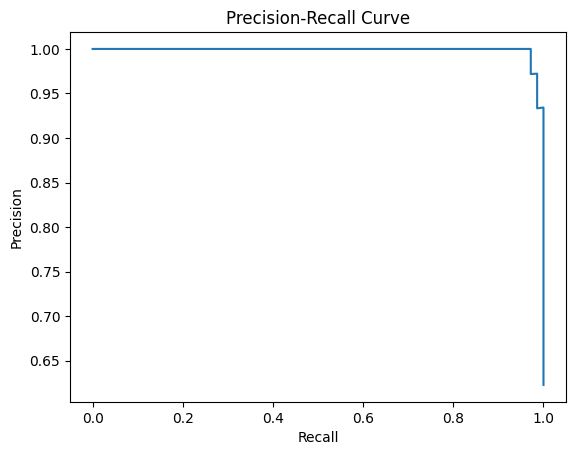

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Calculate predicted probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot the curve
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

Now that we've calculated the curve, we can set a target recall or precision score. Since we’re dealing with cancer in this example, it makes sense to target a recall of 1.0: we want our model to identify cancer every time it exists, even at the cost of a few false positives.

QUESTION 1: The percetage that maximizes the recall, is 0.98-0.99

QUESTION 2: Cual maximiza el con Precision is 0.97-1.00




**False Positive (FP):** recommending a show the user does not like
  → lower cost: the user may feel bored or mildly annoyed.

**False Negative (FN):** failing to recommend a show the user would have enjoyed
  → higher cost: missed engagement opportunity and reduced user satisfaction.



In [ ]:
target_recall = 1.0

# the `thresholds` array has one less element than
# the `precision` and `recall` array so we slice to -1
idx = np.where(recall[:-1] >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print("Optimal decision threshold:", optimal_threshold)

Optimal decision threshold: 0.0848110930022304


In [ ]:
classifications = [
    "immediate follow-up",
    "additional tests recommended",
    "no cancer"
]

conditions = [
    y_pred_proba >= optimal_threshold,
    (y_pred_proba >= 0.01) & (y_pred_proba < optimal_threshold),
    y_pred_proba < 0.01
]

new_labels = np.select(conditions, classifications)

TypeError: Choicelist and default value do not have a common dtype: The DType <class 'numpy.dtypes._PyLongDType'> could not be promoted by <class 'numpy.dtypes.StrDType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes.StrDType'>, <class 'numpy.dtypes._PyLongDType'>)

This marks scores:
- Above 0.08 as requiring immediate follow-up.
- Between 0.01 and 0.08 as lower priority (suggesting additional tests).
- Below 0.01 as safe and not requiring follow-up.

## F-beta

The F1 score is a useful metric when dealing with imbalanced datasets, as it balances the trade-off between precision and recall. However, there might be situations where you want to give more importance to either precision or recall when training your model. This is where the F-beta score comes into play.

The F-beta score is a generalization of the F1 score, allowing you to assign different weights to precision and recall by changing the value of beta. The formula for the F-beta score is defined as:

$ $

$ F_\beta = \frac{(1 + \beta^2) (Precision \times Recall)}{(\beta^2 \times Precision) + Recall} $

$ $

If beta > 1, then recall has a higher importance. If 0 < beta < 1, then precision has a higher importance. The F1 score is just a special case of the F-beta score when beta = 1.

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import fbeta_score, make_scorer

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Define the logistic regression model
log_reg = LogisticRegression(max_iter=5000, solver='liblinear')

# Define the hyperparameter search space
param_dist = {
    'C': np.logspace(-4, 4, 20),
    'penalty': ['l1', 'l2']
}

# Create the F-beta scorer with beta = 2
f_beta_scorer = make_scorer(fbeta_score, beta=2)

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
  log_reg, param_distributions=param_dist,
  n_iter=20, scoring=f_beta_scorer, cv=5
)

# Fit the RandomizedSearchCV object to the data
random_search.fit(X, y)

# Print the best parameters and the corresponding F-beta score
print("Best parameters found: ", random_search.best_params_)
print("Best F-beta score: ", random_search.best_score_)

## Calibration Plot

There are several ways to measure calibration, but one common method is to use a calibration plot. A calibration plot shows the predicted probabilities on the x-axis and the observed frequencies on the y-axis. Ideally, the plot should show a diagonal line, indicating that the predicted probabilities match the true probabilities.

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Calculate predicted probabilities using the calibrated model
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
  y_test, y_pred_proba, n_bins=10)

# Plot the calibration curve
plt.plot(fraction_of_positives, mean_predicted_value, 'x')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('Fraction of positives')
plt.ylabel('Mean predicted value')
plt.title('Calibration Plot')
plt.show()

This curve suggests the model is a bit overconfident, especially when it assigns high probabilities that turn out to actually be benign. That could certainly be worth knowing when you interpret the results.

# Ensemble methods

Ensemble methods combine multiple models to improve overall performance.

**Bagging** is the technique of training multiple base models independently on random subsets of the training data, then combines their predictions through majority voting or averaging.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
base_model = LogisticRegression(max_iter=5000, solver='liblinear')

# Create a bagging ensemble of logistic regression models
bagging_model = BaggingClassifier(
  estimator=base_model, n_estimators=10)
bagging_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_pred = bagging_model.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("Bagging ROC-AUC score:", score)

**Boosting** is the technique of training multiple base models sequentially, with each model learning from the errors of its predecessor

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a logistic regression model
base_model = LogisticRegression(solver='liblinear')

# Create an AdaBoost ensemble of logistic regression models
boosting_model = AdaBoostClassifier(
  estimator=base_model, n_estimators=10)
boosting_model.fit(X_train, y_train)

# Evaluate the ensemble model
y_pred = boosting_model.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("Bagging ROC-AUC score:", score)

Keep in mind that you sacrifice interpretability as you build increasingly sophisticated models. By the time you start employing techniques like bagging or boosting, you may want to consider alternatives to logistic regression, including decision trees or xgboost.

In [ ]:
# XGBoost example (no longer a logistic regression!)

from sklearn.datasets import load_breast_cancer
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the breast cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2)

# Create a xgboost regression model
xgb = XGBClassifier()

# Train on data
xgb.fit(X_train, y_train)

# Evaluate the xgb model
y_pred = xgb.predict(X_test)
score = roc_auc_score(y_test, y_pred)
print("XGB ROC-AUC score:", score)

# Regularization Path Visualization

Visualizing the regularization path can help you understand the effect of regularization on the coefficients of logistic regression models and the trade-off between model complexity and generalization. As the regularization strength `C` increases, the penalty term in the loss function becomes less dominant, allowing the coefficients to take on a wider range of values.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Load the breast cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train a logistic regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Define a range of regularization strengths
C_values = np.logspace(-2, 4, 20)

# Train logistic regression models with different regularization strengths
coefficients = []
for C in C_values:
    model = LogisticRegression(max_iter=5000, penalty='l1', solver='liblinear', C=C)
    model.fit(X_train, y_train)
    coefficients.append(model.coef_)

# Reshape the coefficients array to match the dimensions of the C_values array
coefficients = np.array(coefficients).reshape(len(C_values), -1)

# Plot the regularization path
plt.figure(figsize=(10, 6))
plt.plot(np.log10(C_values), coefficients)
plt.xlabel('log10(C)')
plt.ylabel('Coefficients')
plt.title('Regularization Path')
plt.show()

You can see how the coefficients change as the regularization strength increases. The lines start close to zero at 10e-4 and branch out all over the place as they reach 10e4. This branching effect occurs because the penalty term in the loss function becomes less dominant as the regularization strength increases, allowing the coefficients to take on a wider range of values.

# Statsmodels

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# PREPARE DATA

# Load the breast cancer dataset
data = datasets.load_breast_cancer()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
  data.data, data.target, test_size=0.2, random_state=42)

# Create dataframes for X_train and X_test
X_train_df = pd.DataFrame(X_train, columns=data.feature_names)
X_test_df = pd.DataFrame(X_test, columns=data.feature_names)



# REDUCE COLINEARITY

# Calculate the correlation matrix
corr_matrix = X_train_df.corr().abs()

# Select the upper triangle of the correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find the index of feature columns with correlation greater than 0.9
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

# Drop the highly correlated features
X_train_df = X_train_df.drop(X_train_df[to_drop], axis=1)
X_test_df = X_test_df.drop(X_test_df[to_drop], axis=1)



# FIT MODEL

# Add a constant term to the features
X_train_sm = sm.add_constant(X_train_df)

# Perform logistic regression
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Print the summary of the results
print(result.summary())

# Bias vs Variance


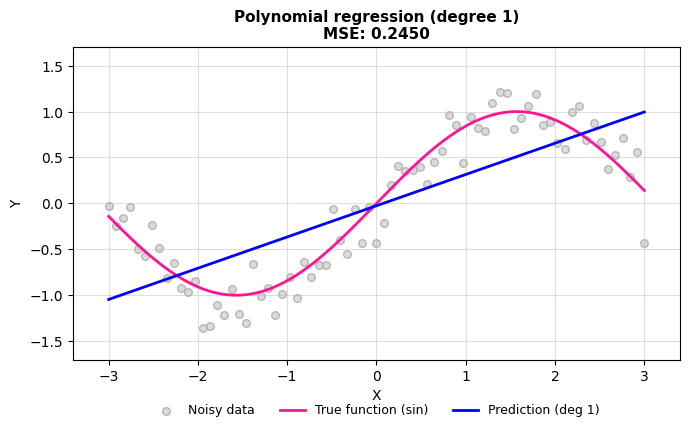

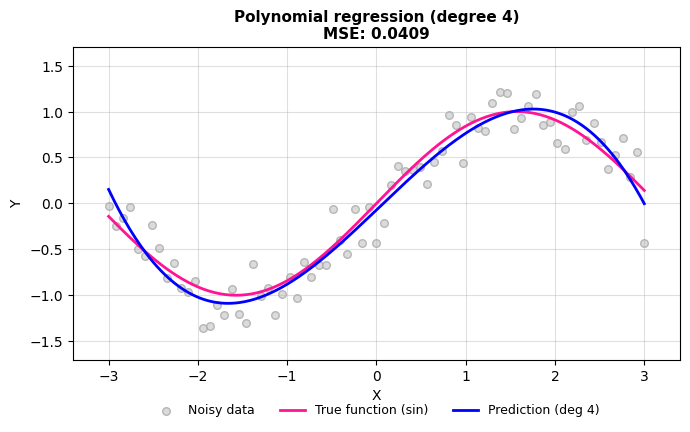

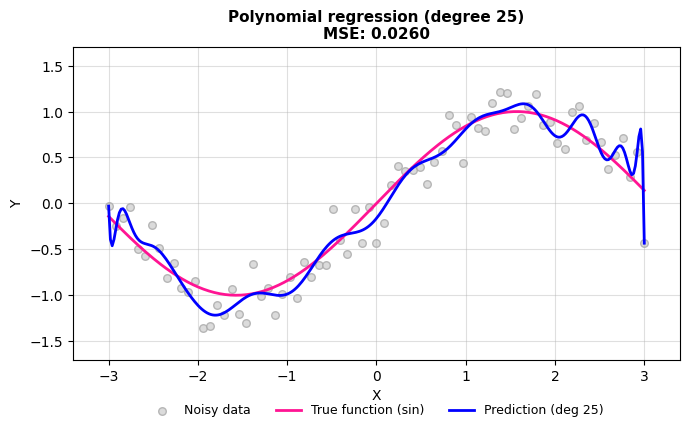

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = np.linspace(-3, 3, 75)
y_true = np.sin(X)
ruido = np.random.normal(0, 0.22, len(X))
y_noisy = y_true + ruido

X_curva = np.linspace(-3, 3, 300)
y_curva_true = np.sin(X_curva)

grados = [1, 4, 25]

for grado in grados:
    coeficientes = np.polyfit(X, y_noisy, grado)

    y_pred_train = np.polyval(coeficientes, X)
    y_pred_curva = np.polyval(coeficientes, X_curva)

    mse = np.mean((y_noisy - y_pred_train) ** 2)

    plt.figure(figsize=(7, 4.5))
    plt.scatter(X, y_noisy, color='lightgray', edgecolors='darkgray', s=30, alpha=0.8, label='Noisy data')
    plt.plot(X_curva, y_curva_true, color='deeppink', lw=2, label='True function (sin)')
    plt.plot(X_curva, y_pred_curva, color='blue', lw=2, label=f'Prediction (deg {grado})')

    plt.title(f"Polynomial regression (degree {grado})\nMSE: {mse:.4f}", fontsize=11, fontweight='bold')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(-3.4, 3.4)
    plt.ylim(-1.7, 1.7)
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

## Análisis

El experimento demuestra cómo la complejidad de un modelo (el grado del polinomio) afecta directamente su capacidad de generalización al balancear el sesgo (Bias) y la varianza (Variance):

* **Polinomio Grado 1 (Subajuste / Underfitting):** El modelo sufre de un **Alto Sesgo (High Bias)** y una **Baja Varianza**. Al ser una simple línea recta, es demasiado rígido para entender la curvatura real de la función seno. Aunque el modelo es muy estable y no cambiaría casi nada con datos nuevos (baja varianza), su error (MSE) es el más alto porque no tiene la flexibilidad matemática para aprender el patrón subyacente.

* **Polinomio Grado 4 (Ajuste Óptimo / Sweet Spot):** Representa el equilibrio perfecto con **Bajo Sesgo y Baja Varianza**. El polinomio tiene la flexibilidad exacta para describir la curva senoidal pura sin dejarse engañar por los pequeños piquitos del ruido aleatorio. Es el modelo ideal porque aprendió la verdadera naturaleza del fenómeno y generalizará de forma excelente ante datos futuros.

* **Polinomio Grado 25 (Sobreajuste / Overfitting):** El modelo tiene un **Sesgo casi nulo, pero una Alta Varianza (High Variance)**. Al darle demasiados grados de libertad, el polinomio memoriza el ruido de cada punto en lugar de aprender la tendencia general, creando oscilaciones salvajes y artificiales (especialmente notorias en los extremos). Logra el MSE más bajo en los datos conocidos, pero fallará drásticamente ante datos nuevos porque cualquier cambio mínimo en la muestra alteraría por completo la forma de la curva ajustada.